# **explosion**

demonstrate by training a simple neural network with a deliberately high learning rate and initial weights. We will track and plot the magnitude of the gradients over training epochs to observe their explosion.

Initial weight: 0.9626, Initial bias: 10.9467

Epoch 1/50, Loss: 29.5346, Gradient Magnitude: 27.6880, Weight: -12.3055, Bias: 6.9955
Epoch 6/50, Loss: 37543709898188288.0000, Gradient Magnitude: 2448731798.0609, Weight: 1181588981.6377, Bias: 169623663.2281
Epoch 11/50, Loss: 300080076363003779329697408614400.0000, Gradient Magnitude: 218922908304401024.0000, Weight: -105637087783669872.0000, Bias: -15164790583746186.0000
Epoch 16/50, Loss: 2398485724352230947237340778645162056474746159104.0000, Gradient Magnitude: 19572269947411067849146368.0000, Weight: 9444226803736383292702720.0000, Bias: 1355771204118755422502912.0000
Epoch 21/50, Loss: 19170662176726539501928231232147450444493443061766282659974086656.0000, Gradient Magnitude: 1749811172623770790154235988148224.0000, Weight: -844338118285393028405529262686208.0000, Bias: -121209425726441370167551826329600.0000
Epoch 26/50, Loss: 153227632152544643554876336103267766085177820211405977690194522224289614764441600.0000, Gradient Magni

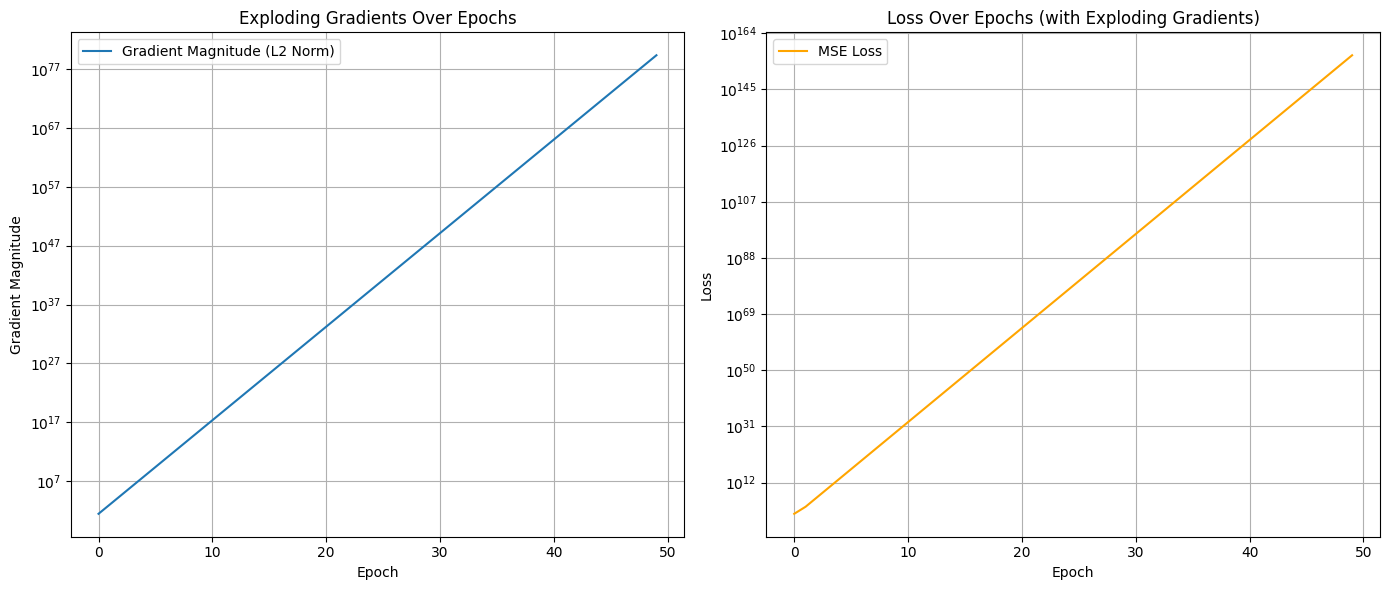

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate a simple dataset (linear regression problem)
X = np.random.rand(100, 1) * 10  # 100 samples, 1 feature
y = 2 * X + 1 + np.random.randn(100, 1) * 2 # y = 2x + 1 + noise

# 2. Define a simple neural network (single neuron, linear activation for simplicity)
# We'll manually implement forward and backward pass

# Initialize weights and bias (deliberately large to exacerbate the problem)
w = np.random.randn(1, 1) * 5 # Initial weight
b = np.random.randn(1, 1) * 5 # Initial bias

learning_rate = 0.5 # Deliberately high learning rate
n_epochs = 50 # Number of training epochs

gradient_magnitudes = [] # To store L2 norm of gradients
losses = [] # To store Mean Squared Error

print(f"Initial weight: {w[0][0]:.4f}, Initial bias: {b[0][0]:.4f}\n")

for epoch in range(n_epochs):
    # Forward pass
    y_pred = X @ w + b

    # Calculate loss (Mean Squared Error)
    loss = np.mean((y_pred - y)**2)
    losses.append(loss)

    # Backward pass (calculate gradients)
    # dL/dy_pred = 2 * (y_pred - y) / N (where N is number of samples)
    # dL/dw = dL/dy_pred * dy_pred/dw = dL/dy_pred * X
    # dL/db = dL/dy_pred * dy_pred/db = dL/dy_pred * 1

    d_loss_d_y_pred = 2 * (y_pred - y) / len(X)
    grad_w = X.T @ d_loss_d_y_pred
    grad_b = np.sum(d_loss_d_y_pred, axis=0)

    # Store gradient magnitude (L2 norm)
    gradient_magnitude = np.sqrt(np.sum(grad_w**2) + np.sum(grad_b**2))
    gradient_magnitudes.append(gradient_magnitude)

    # Update weights and bias
    w -= learning_rate * grad_w
    b -= learning_rate * grad_b

    if epoch % 5 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {loss:.4f}, Gradient Magnitude: {gradient_magnitude:.4f}, Weight: {w[0][0]:.4f}, Bias: {b[0][0]:.4f}")

# 3. Plot the gradient magnitudes and loss
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(range(n_epochs), gradient_magnitudes, label='Gradient Magnitude (L2 Norm)')
plt.title('Exploding Gradients Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Gradient Magnitude')
plt.yscale('log') # Use log scale to better visualize explosion
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(n_epochs), losses, label='MSE Loss', color='orange')
plt.title('Loss Over Epochs (with Exploding Gradients)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log') # Use log scale for loss as well
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Observations
In the plots above, you should observe the following:

1. Exploding Gradients: The 'Gradient Magnitude' plot shows a sharp, often exponential, increase in the gradient values early in the training. This indicates that the gradients are growing out of control.
2. Diverging Loss: The 'MSE Loss' plot will also show a rapid increase in loss (or NaN/infinity values) as the gradients explode, demonstrating that the model is failing to learn and is diverging.

This behavior is a clear sign of the Exploding Gradient Problem. To mitigate this, techniques like gradient clipping, using smaller learning rates, or batch normalization are often employed.